# Trabalho Final — Análise Avançada de Dados
## Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?

**Disciplina:** Análise Avançada de Dados  
**Professora:** Ma. Heloisa Guimarães  
**Instituição:** Centro Universitário Santo Agostinho — UNIFSA  
**Base de dados:** State of Data Brazil 2024–2025 (Data Hackers + Bain & Company)  
**Link:** https://www.kaggle.com/datasets/datahackers/state-of-data-brazil-20242025

---

### Estrutura do notebook
1. Carregamento e reconhecimento da base  
2. Limpeza e decisões documentadas  
3. Análise univariada  
4. Análise bivariada  
5. Síntese visual — resposta à pergunta central  

---
## Etapa 1 — Carregamento e Reconhecimento da Base

Nesta etapa carregamos o CSV, inspecionamos suas dimensões, tipos de dados e valores nulos. Com 403 colunas e 5.217 linhas, é essencial entender a estrutura antes de qualquer análise.

Também renomeamos as colunas-chave com nomes legíveis, usando o dicionário de dados oficial do Kaggle, para facilitar a leitura do código e dos gráficos.

In [3]:
import os
print("Pasta atual:", os.getcwd())
print("\nArquivos nessa pasta:")
for f in os.listdir('.'):
    print(f)

Pasta atual: /Users/rodofodheymison/Documents

Arquivos nessa pasta:
07_sintese_fatores.png
.DS_Store
analise_state_of_data.ipynb
.localized
archive (1) (1).zip
files (3)
files (3).zip
rodolfo-dheymison-analise (1).ipynb
document_pdf (1).pdf
AnaliseDadosAvnc


In [4]:
import zipfile, os

# Extrair o zip
zip_path = '/Users/rodofodheymison/Documents/archive (1) (1).zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/Users/rodofodheymison/Documents/')
    print("Arquivos extraídos:", z.namelist())

Arquivos extraídos: ['Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais globais
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
COR_PRINCIPAL = '#1B4F72'
COR_DESTAQUE  = '#E74C3C'
COR_SECUNDARIA = '#2E86C1'

# ─── Carregamento ───────────────────────────────────────────────────────────
# Ajuste o caminho abaixo conforme onde você salvou o CSV
# ─── Carregamento ───────────────────────────────────────────────────────────
CAMINHO_CSV = '/Users/rodofodheymison/Documents/Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv'

df_raw = pd.read_csv(CAMINHO_CSV)
print(f'Shape original: {df_raw.shape}')
print(f'Linhas (respondentes): {df_raw.shape[0]:,}')
print(f'Colunas: {df_raw.shape[1]:,}')

Shape original: (5217, 403)
Linhas (respondentes): 5,217
Colunas: 403


In [6]:
# ─── Tipos de dados das colunas principais ──────────────────────────────────
colunas_inspecao = [
    '2.h_faixa_salarial', '2.f_cargo_atual', '2.g_nivel',
    '1.b_genero', '1.c_cor/raca/etnia', '1.i.2_regiao_onde_mora',
    '1.l_nivel_de_ensino', '2.i_tempo_de_experiencia_em_dados',
    '1.a.1_faixa_idade', '2.c_numero_de_funcionarios'
]
print('Tipos e nulos nas colunas-chave:')
print(df_raw[colunas_inspecao].dtypes)
print('\nValores nulos:')
print(df_raw[colunas_inspecao].isnull().sum())

Tipos e nulos nas colunas-chave:
2.h_faixa_salarial                   object
2.f_cargo_atual                      object
2.g_nivel                            object
1.b_genero                           object
1.c_cor/raca/etnia                   object
1.i.2_regiao_onde_mora               object
1.l_nivel_de_ensino                  object
2.i_tempo_de_experiencia_em_dados    object
1.a.1_faixa_idade                    object
2.c_numero_de_funcionarios           object
dtype: object

Valores nulos:
2.h_faixa_salarial                    354
2.f_cargo_atual                      1399
2.g_nivel                            1399
1.b_genero                              0
1.c_cor/raca/etnia                      0
1.i.2_regiao_onde_mora                142
1.l_nivel_de_ensino                     0
2.i_tempo_de_experiencia_em_dados     354
1.a.1_faixa_idade                       0
2.c_numero_de_funcionarios            354
dtype: int64


In [7]:
# ─── Renomeando colunas-chave (dicionário oficial) ───────────────────────────
# Fonte: dicionário de dados disponível na página do dataset no Kaggle.
# Renomeamos apenas as colunas usadas nesta análise para não poluir o dataframe.

renomear = {
    '1.a.1_faixa_idade'                    : 'faixa_idade',
    '1.b_genero'                           : 'genero',
    '1.c_cor/raca/etnia'                   : 'raca_etnia',
    '1.d_pcd'                              : 'pcd',
    '1.i.1_uf_onde_mora'                   : 'uf',
    '1.i.2_regiao_onde_mora'               : 'regiao',
    '1.l_nivel_de_ensino'                  : 'nivel_ensino',
    '1.m_área_de_formação'                 : 'area_formacao',
    '2.a_situação_de_trabalho'             : 'situacao_trabalho',
    '2.b_setor'                            : 'setor',
    '2.c_numero_de_funcionarios'           : 'tamanho_empresa',
    '2.d_atua_como_gestor'                 : 'e_gestor',
    '2.f_cargo_atual'                      : 'cargo',
    '2.g_nivel'                            : 'senioridade',
    '2.h_faixa_salarial'                   : 'faixa_salarial',
    '2.i_tempo_de_experiencia_em_dados'    : 'exp_dados',
    '2.j_tempo_de_experiencia_em_ti'       : 'exp_ti',
    '2.k_satisfeito_atualmente'            : 'satisfeito',
    '4.d.1_SQL'                            : 'usa_sql',
    '4.d.2_R'                              : 'usa_r',
    '4.d.3_Python'                         : 'usa_python',
}

df = df_raw.rename(columns=renomear).copy()
print('Colunas renomeadas com sucesso:', len(renomear))
print(df[list(renomear.values())[:10]].head(3))

Colunas renomeadas com sucesso: 21
  faixa_idade     genero raca_etnia  pcd  uf   regiao            nivel_ensino  \
0       17-21  Masculino     Branca  Não  RS      Sul  Estudante de Graduação   
1       17-21  Masculino     Branca  Não  SC      Sul  Estudante de Graduação   
2       17-21  Masculino      Parda  Não  SP  Sudeste  Estudante de Graduação   

                                       area_formacao situacao_trabalho  \
0  Computação / Engenharia de Software / Sistemas...        Estagiário   
1  Computação / Engenharia de Software / Sistemas...        Estagiário   
2  Computação / Engenharia de Software / Sistemas...   Empregado (CLT)   

                setor  
0           Marketing  
1  Finanças ou Bancos  
2           Indústria  


---
## Etapa 2 — Limpeza e Decisões Documentadas

Dados reais chegam sujos. Abaixo tratamos cada problema identificado, documentando a decisão tomada e suas implicações.

### Problema 1 — Faixas salariais em texto (variável categórica ordinal)

**Problema:** A coluna `faixa_salarial` contém strings como `"de R$ 8.001/mês a R$ 12.000/mês"`. Não é possível calcular médias, correlações ou distribuições sem converter para número.  

**Decisão:** Extraímos os dois limites de cada faixa com expressão regular e calculamos o **ponto médio** aritmético. Para a faixa aberta `"Menos de R$ 1.000/mês"` usamos R$ 750 como estimativa. Para `"Acima de R$ 40.001/mês"` usamos R$ 45.000 como estimativa conservadora.  

**Limitação:** O ponto médio é uma aproximação. A distribuição real dentro de cada faixa é desconhecida, o que introduz imprecisão nas métricas calculadas. Toda análise numérica de salário deve ser interpretada com essa ressalva.

In [8]:
# ─── Conversão das faixas salariais para ponto médio ────────────────────────

def faixa_para_ponto_medio(faixa):
    """Extrai os dois valores de uma faixa salarial e retorna o ponto médio."""
    if pd.isna(faixa):
        return np.nan
    faixa = str(faixa)
    # Casos especiais
    if 'Menos de' in faixa or 'menos de' in faixa:
        return 750.0       # estimativa: metade de R$1.000
    if 'Acima de' in faixa or 'acima de' in faixa:
        return 45000.0     # estimativa conservadora para aberto superior
    # Extrai todos os números (ex: '8001' e '12000')
    numeros = [float(n.replace('.', '').replace(',', '.')) 
               for n in __import__('re').findall(r'[\d\.]+', faixa)
               if len(n.replace('.','')) >= 3]   # ignora números menores (ex: 'R$')
    if len(numeros) >= 2:
        return (numeros[0] + numeros[1]) / 2
    elif len(numeros) == 1:
        return numeros[0]
    return np.nan

df['salario_medio'] = df['faixa_salarial'].apply(faixa_para_ponto_medio)

# Verificação
print('Exemplos de conversão:')
amostra = df[['faixa_salarial','salario_medio']].dropna().drop_duplicates().sort_values('salario_medio')
print(amostra.to_string(index=False))
print(f'\nNulos após conversão: {df["salario_medio"].isnull().sum()}')

Exemplos de conversão:
                  faixa_salarial  salario_medio
           Menos de R$ 1.000/mês          750.0
  de R$ 1.001/mês a R$ 2.000/mês         1500.5
  de R$ 2.001/mês a R$ 3.000/mês         2500.5
  de R$ 3.001/mês a R$ 4.000/mês         3500.5
  de R$ 4.001/mês a R$ 6.000/mês         5000.5
  de R$ 6.001/mês a R$ 8.000/mês         7000.5
 de R$ 8.001/mês a R$ 12.000/mês        10000.5
de R$ 12.001/mês a R$ 16.000/mês        14000.5
de R$ 16.001/mês a R$ 20.000/mês        18000.5
de R$ 20.001/mês a R$ 25.000/mês        22500.5
de R$ 25.001/mês a R$ 30.000/mês        27500.5
de R$ 30.001/mês a R$ 40.000/mês        35000.5
          Acima de R$ 40.001/mês        45000.0

Nulos após conversão: 354


### Problema 2 — Missings em campos sensíveis (gênero e raça)

**Problema:** Campos como `genero` e `raca_etnia` contêm a opção `"Prefiro não informar"`, que não é um erro de coleta — é uma escolha deliberada do respondente.

**Decisão:** **Não imputamos** esses campos. Mantemos `"Prefiro não informar"` como categoria válida nas análises. Imputar (ex: atribuir o gênero majoritário) distorceria a distribuição e violaria a privacidade dos respondentes.

**Implicação:** As análises de salário por gênero e raça representam apenas os respondentes que optaram por informar. Os resultados não podem ser generalizados para o grupo que preferiu não informar.

In [9]:
# ─── Tratamento de missings em dados sensíveis ───────────────────────────────
# NÃO imputamos — apenas documentamos a decisão

print('Distribuição de gênero (incluindo não-resposta):')
print(df['genero'].value_counts(dropna=False))
print(f'\nTaxa de não-resposta em gênero: {(df["genero"]=="Prefiro não informar").mean()*100:.1f}%')

print('\nDistribuição de raça/etnia (incluindo não-resposta):')
print(df['raca_etnia'].value_counts(dropna=False))
print(f'\nTaxa de não-resposta em raça: {(df["raca_etnia"]=="Prefiro não informar").mean()*100:.1f}%')

Distribuição de gênero (incluindo não-resposta):
genero
Masculino               3968
Feminino                1226
Prefiro não informar      15
Outro                      8
Name: count, dtype: int64

Taxa de não-resposta em gênero: 0.3%

Distribuição de raça/etnia (incluindo não-resposta):
raca_etnia
Branca                  3478
Parda                   1180
Preta                    352
Amarela                  155
Prefiro não informar      37
Indígena                  10
Outra                      5
Name: count, dtype: int64

Taxa de não-resposta em raça: 0.7%


### Problema 3 — Missings em cargo e senioridade

**Problema:** As colunas `cargo` e `senioridade` têm ~1.399 nulos (~26,8%). Ao inspecionar a base, esses nulos correspondem majoritariamente a respondentes fora do mercado de dados (estudantes, desempregados, etc.).

**Decisão:** Para a análise salarial, **filtramos** apenas respondentes com cargo e salário preenchidos. Isso restringe a análise a profissionais atualmente empregados em dados, que é o público relevante para responder à pergunta central.

**Implicação:** A amostra final é menor, mas mais coerente com a pergunta. Perdemos informação sobre quem está em transição de carreira.

In [10]:
# ─── Filtro: apenas profissionais com cargo e salário informados ─────────────
print(f'Respondentes antes do filtro: {len(df):,}')

df_analise = df.dropna(subset=['cargo', 'salario_medio', 'senioridade']).copy()

print(f'Respondentes após filtro (cargo + salário + senioridade preenchidos): {len(df_analise):,}')
print(f'Removidos: {len(df) - len(df_analise):,} ({(len(df)-len(df_analise))/len(df)*100:.1f}%)')

Respondentes antes do filtro: 5,217
Respondentes após filtro (cargo + salário + senioridade preenchidos): 3,818
Removidos: 1,399 (26.8%)


### Problema 4 — Inconsistência de cargo/título

**Problema:** Títulos como `"Analista de Dados/Data Analyst"` já vêm padronizados no dataset como duplas PT/EN, mas são longos. Criamos uma versão simplificada para facilitar a visualização.

**Decisão:** Agrupamos em categorias mais amplas: *Analista de Dados*, *Cientista de Dados*, *Engenheiro de Dados*, *Analytics Engineer*, *Analista de BI*, *Outros*.

In [11]:
# ─── Padronização de cargos ──────────────────────────────────────────────────
mapa_cargo = {
    'Analista de Dados/Data Analyst'                                  : 'Analista de Dados',
    'Cientista de Dados/Data Scientist'                               : 'Cientista de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect'                : 'Engenheiro de Dados',
    'Analytics Engineer'                                              : 'Analytics Engineer',
    'Analista de BI/BI Analyst'                                       : 'Analista de BI',
    'Analista de Negócios/Business Analyst'                           : 'Business Analyst',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer'          : 'ML/AI Engineer',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)'      : 'Product Manager',
    'Arquiteto de Dados/Data Architect'                               : 'Arquiteto de Dados',
}

df_analise['cargo_grupo'] = df_analise['cargo'].map(mapa_cargo).fillna('Outros')

print('Distribuição de cargos (padronizados):')
print(df_analise['cargo_grupo'].value_counts())

Distribuição de cargos (padronizados):
cargo_grupo
Analista de Dados      957
Cientista de Dados     687
Engenheiro de Dados    613
Outros                 522
Analista de BI         396
Analytics Engineer     228
Business Analyst       184
ML/AI Engineer         103
Product Manager         80
Arquiteto de Dados      48
Name: count, dtype: int64


---
## Etapa 3 — Análise Univariada

Antes de cruzar variáveis com salário, entendemos a distribuição individual de cada uma. Analisamos: **salário**, **senioridade**, **experiência em dados** e **nível de ensino**.

### 3.1 — Salário (variável contínua derivada)

In [12]:
# ─── Estatísticas descritivas do salário ────────────────────────────────────
sal = df_analise['salario_medio'].dropna()

stats_sal = {
    'Média'           : sal.mean(),
    'Mediana'         : sal.median(),
    'Moda'            : sal.mode()[0],
    'Desvio Padrão'   : sal.std(),
    'Variância'       : sal.var(),
    'Amplitude'       : sal.max() - sal.min(),
    'Mínimo'          : sal.min(),
    'Máximo'          : sal.max(),
    'Assimetria'      : sal.skew(),
    'Curtose'         : sal.kurtosis(),
}

for k, v in stats_sal.items():
    if 'imetria' in k or 'rtose' in k:
        print(f'{k:20s}: {v:.4f}')
    else:
        print(f'{k:20s}: R$ {v:>10,.2f}')

Média               : R$   9,866.65
Mediana             : R$  10,000.50
Moda                : R$  10,000.50
Desvio Padrão       : R$   7,075.96
Variância           : R$ 50,069,264.38
Amplitude           : R$  44,250.00
Mínimo              : R$     750.00
Máximo              : R$  45,000.00
Assimetria          : 2.0020
Curtose             : 5.9055


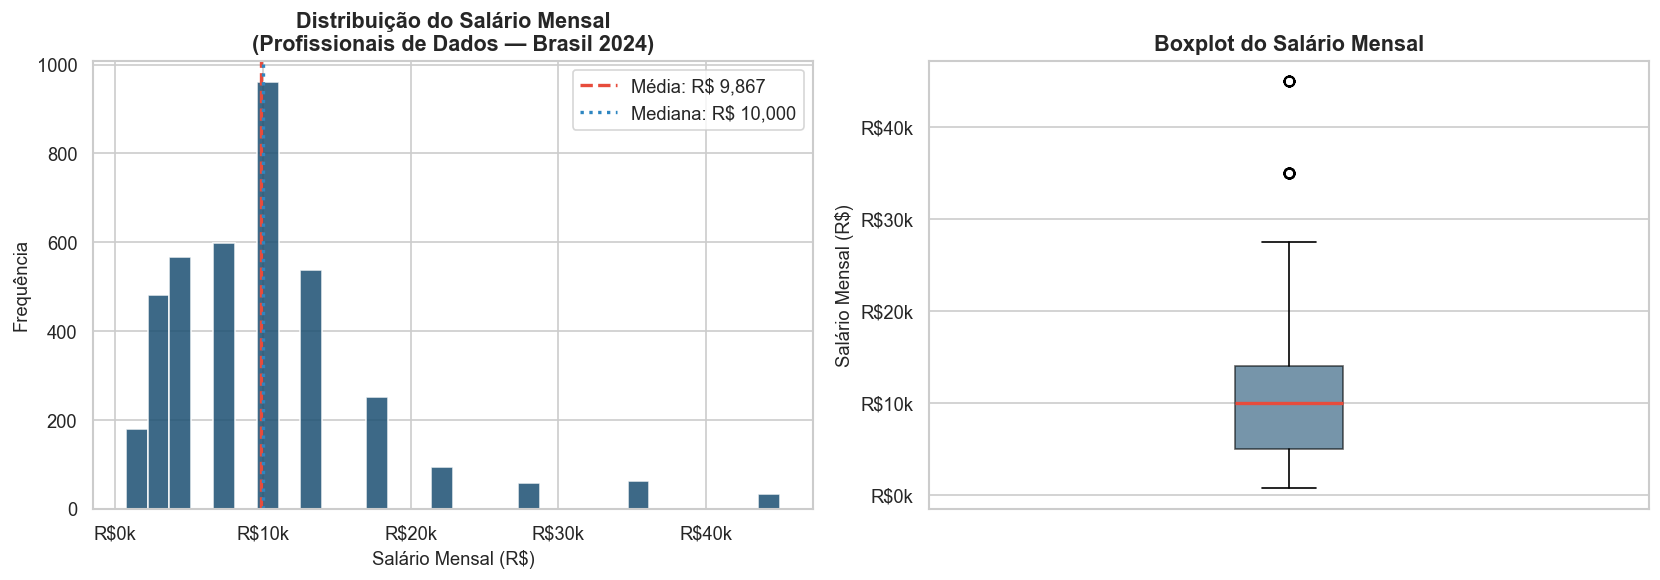


Interpretação: A distribuição salarial é assimétrica à direita (assimetria = 2.00), o que indica que a maioria dos profissionais ganha abaixo da média.
A mediana (R$ 10,000) é mais representativa do salário típico do que a média (R$ 9,867), pois a média é inflacionada pelos salários mais altos.


In [13]:
# ─── Histograma + Boxplot do salário ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1 = axes[0]
ax1.hist(sal, bins=30, color=COR_PRINCIPAL, edgecolor='white', alpha=0.85)
ax1.axvline(sal.mean(),   color=COR_DESTAQUE,    lw=2, linestyle='--', label=f'Média: R$ {sal.mean():,.0f}')
ax1.axvline(sal.median(), color=COR_SECUNDARIA, lw=2, linestyle=':',  label=f'Mediana: R$ {sal.median():,.0f}')
ax1.set_title('Distribuição do Salário Mensal\n(Profissionais de Dados — Brasil 2024)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Salário Mensal (R$)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.legend()
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))

# Boxplot
ax2 = axes[1]
ax2.boxplot(sal, vert=True, patch_artist=True,
            boxprops=dict(facecolor=COR_PRINCIPAL, alpha=0.6),
            medianprops=dict(color=COR_DESTAQUE, lw=2),
            flierprops=dict(marker='o', color='gray', alpha=0.4))
ax2.set_title('Boxplot do Salário Mensal', fontsize=13, fontweight='bold')
ax2.set_ylabel('Salário Mensal (R$)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
ax2.set_xticks([])

plt.tight_layout()
plt.savefig('plot_01_distribuicao_salario.png', bbox_inches='tight')
plt.show()

print(f'\nInterpretação: A distribuição salarial é assimétrica à direita (assimetria = {sal.skew():.2f}),'
      f' o que indica que a maioria dos profissionais ganha abaixo da média.\n'
      f'A mediana (R$ {sal.median():,.0f}) é mais representativa do salário típico do que a média'
      f' (R$ {sal.mean():,.0f}), pois a média é inflacionada pelos salários mais altos.')

### 3.2 — Senioridade

Frequências — Senioridade:
senioridade
Sênior    1573
Pleno     1377
Júnior     868
Name: count, dtype: int64
Moda: Sênior
Proporção Sênior: 41.2%


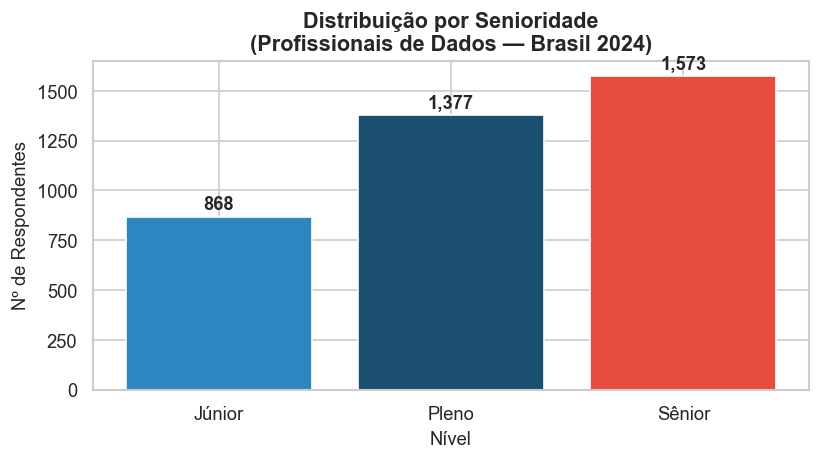

In [14]:
# ─── Análise univariada: Senioridade ────────────────────────────────────────
sen = df_analise['senioridade'].value_counts()

print('Frequências — Senioridade:')
print(sen)
print(f'Moda: {sen.idxmax()}')
print(f'Proporção Sênior: {sen["Sênior"]/sen.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
ordem = ['Júnior', 'Pleno', 'Sênior']
cores = [COR_SECUNDARIA, COR_PRINCIPAL, COR_DESTAQUE]
bars = ax.bar(ordem, [sen.get(o, 0) for o in ordem], color=cores, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribuição por Senioridade\n(Profissionais de Dados — Brasil 2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nível', fontsize=11)
ax.set_ylabel('Nº de Respondentes', fontsize=11)
plt.tight_layout()
plt.savefig('plot_02_senioridade.png', bbox_inches='tight')
plt.show()

### 3.3 — Experiência em Dados

Frequências — Experiência em Dados:
  Não tenho experiência na área de dados       :   188
  Menos de 1 ano                               :   318
  de 1 a 2 anos                                :   866
  de 3 a 4 anos                                : 1,226
  de 5 a 6 anos                                :   624
  de 7 a 10 anos                               :   326
  Mais de 10 anos                              :   270
Moda: de 3 a 4 anos


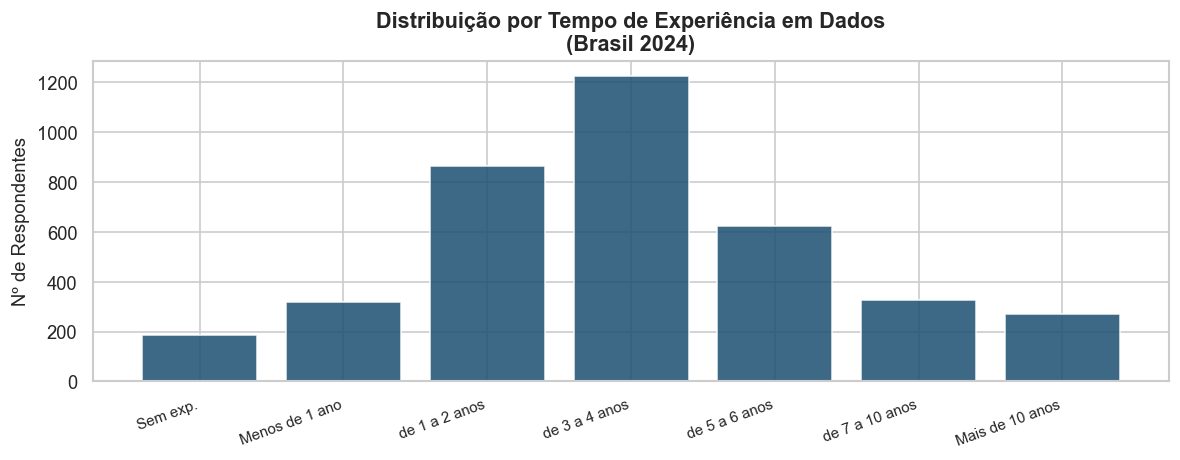

In [15]:
# ─── Análise univariada: Experiência em dados ────────────────────────────────
exp = df_analise['exp_dados'].value_counts()

# Ordem cronológica
ordem_exp = [
    'Não tenho experiência na área de dados',
    'Menos de 1 ano', 'de 1 a 2 anos', 'de 3 a 4 anos',
    'de 5 a 6 anos', 'de 7 a 10 anos', 'Mais de 10 anos'
]
ordem_exp = [o for o in ordem_exp if o in exp.index]

print('Frequências — Experiência em Dados:')
for o in ordem_exp:
    print(f'  {o:45s}: {exp.get(o,0):>5,}')
print(f'Moda: {exp.idxmax()}')

fig, ax = plt.subplots(figsize=(10, 4))
valores = [exp.get(o, 0) for o in ordem_exp]
ax.bar(range(len(ordem_exp)), valores, color=COR_PRINCIPAL, edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(ordem_exp)))
ax.set_xticklabels([o.replace('Não tenho experiência na área de dados', 'Sem exp.') for o in ordem_exp],
                   rotation=20, ha='right', fontsize=9)
ax.set_title('Distribuição por Tempo de Experiência em Dados\n(Brasil 2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de Respondentes', fontsize=11)
plt.tight_layout()
plt.savefig('plot_03_experiencia.png', bbox_inches='tight')
plt.show()

### 3.4 — Nível de Ensino

Frequências — Nível de Ensino:
nivel_ensino
Graduação/Bacharelado         1374
Pós-graduação                 1323
Estudante de Graduação         465
Mestrado                       438
Doutorado ou Phd               150
Não tenho graduação formal      64
Prefiro não informar             4
Name: count, dtype: int64

Moda: Graduação/Bacharelado
% com graduação ou mais: 98.2%


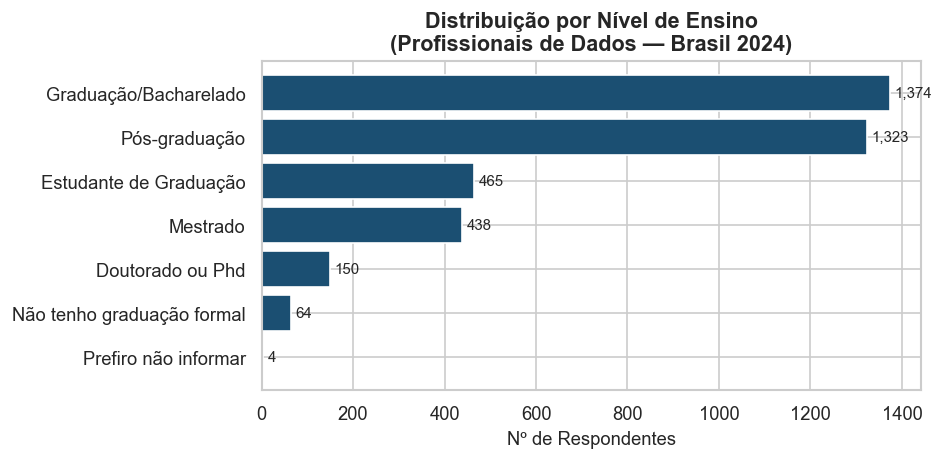

In [16]:
# ─── Análise univariada: Nível de ensino ────────────────────────────────────
ens = df_analise['nivel_ensino'].value_counts()

print('Frequências — Nível de Ensino:')
print(ens)

# Estatísticas adicionais
print(f'\nModa: {ens.idxmax()}')
print(f'% com graduação ou mais: {ens[ens.index.str.contains("Gradua|Pós|Mestrado|Doutorado")].sum() / ens.sum() * 100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ens_sorted = ens.sort_values(ascending=True)
bars = ax.barh(ens_sorted.index, ens_sorted.values, color=COR_PRINCIPAL, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=9)
ax.set_title('Distribuição por Nível de Ensino\n(Profissionais de Dados — Brasil 2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nº de Respondentes', fontsize=11)
plt.tight_layout()
plt.savefig('plot_04_ensino.png', bbox_inches='tight')
plt.show()

---
## Etapa 4 — Análise Bivariada

Cruzamos o salário com as principais variáveis explicativas. Para cada cruzamento calculamos a correlação de Spearman (adequada para variáveis ordinais) ou comparamos medianas entre grupos.

### 4.1 — Salário × Senioridade

Estatísticas salariais por senioridade:
                 Média    Mediana Desvio Padrão     N
senioridade                                          
Júnior        R$ 4,165   R$ 3,500      R$ 3,225   868
Pleno         R$ 8,048   R$ 7,000      R$ 4,172  1377
Sênior       R$ 14,605  R$ 14,000      R$ 7,569  1573

Correlação de Spearman (senioridade × salário): ρ = 0.734, p = 0.00e+00


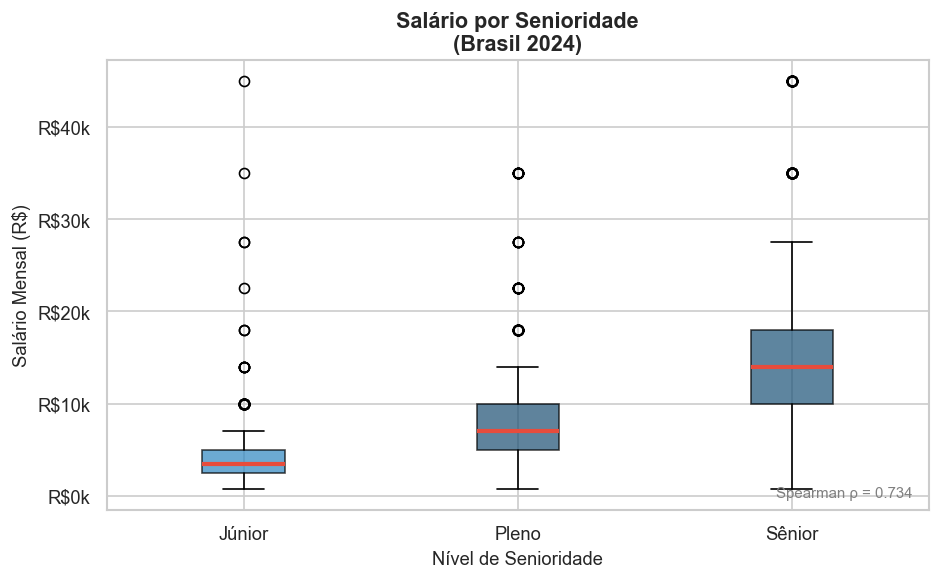


Interpretação: Há correlação forte e positiva (ρ=0.73) entre senioridade e salário. A progressão de Júnior para Sênior representa uma elevação expressiva na mediana salarial.


In [17]:
# ─── Salário × Senioridade ──────────────────────────────────────────────────
ordem_sen = ['Júnior', 'Pleno', 'Sênior']

# Estatísticas por grupo
tab_sen = df_analise.groupby('senioridade')['salario_medio'].agg(['mean','median','std','count'])
tab_sen = tab_sen.reindex(ordem_sen)
tab_sen.columns = ['Média', 'Mediana', 'Desvio Padrão', 'N']
tab_sen[['Média','Mediana','Desvio Padrão']] = tab_sen[['Média','Mediana','Desvio Padrão']].applymap(lambda x: f'R$ {x:,.0f}')
print('Estatísticas salariais por senioridade:')
print(tab_sen.to_string())

# Correlação de Spearman (codificando senioridade como ordinal)
mapa_ord = {'Júnior': 1, 'Pleno': 2, 'Sênior': 3}
df_temp = df_analise[['senioridade','salario_medio']].dropna()
df_temp['sen_num'] = df_temp['senioridade'].map(mapa_ord)
rho, pval = stats.spearmanr(df_temp['sen_num'], df_temp['salario_medio'])
print(f'\nCorrelação de Spearman (senioridade × salário): ρ = {rho:.3f}, p = {pval:.2e}')

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
grupos = [df_analise[df_analise['senioridade'] == s]['salario_medio'].dropna() for s in ordem_sen]
bp = ax.boxplot(grupos, labels=ordem_sen, patch_artist=True,
                medianprops=dict(color=COR_DESTAQUE, lw=2.5))
cores_box = [COR_SECUNDARIA, COR_PRINCIPAL, '#1A5276']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_title('Salário por Senioridade\n(Brasil 2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nível de Senioridade', fontsize=11)
ax.set_ylabel('Salário Mensal (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
ax.text(0.98, 0.02, f'Spearman ρ = {rho:.3f}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('plot_05_salario_senioridade.png', bbox_inches='tight')
plt.show()

print(f'\nInterpretação: Há correlação forte e positiva (ρ={rho:.2f}) entre senioridade e salário.'
      f' A progressão de Júnior para Sênior representa uma elevação expressiva na mediana salarial.')

### 4.2 — Salário × Gênero (controlado por senioridade)

Salário por gênero (geral):
           Mediana         Média     N
genero                                
Feminino    7000.5   8556.699364   943
Masculino  10000.5  10283.905878  2858

Diferença na mediana: homens ganham 42.9% a mais que mulheres

Mediana salarial por gênero E senioridade:
genero        Feminino  Masculino
senioridade                      
Júnior        R$ 3,500   R$ 3,500
Pleno         R$ 7,000   R$ 7,000
Sênior       R$ 10,000  R$ 14,000


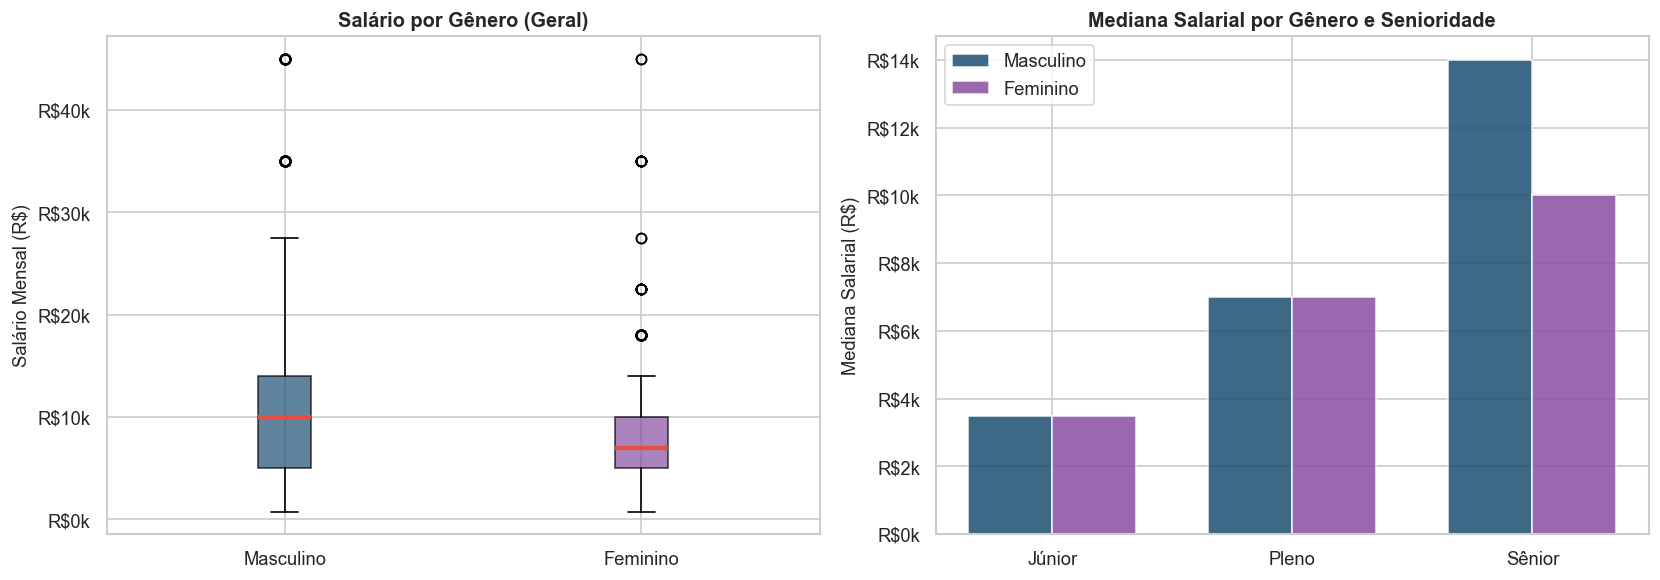


Interpretação: A diferença salarial entre gêneros persiste mesmo quando controlamos pela senioridade, sugerindo que não é apenas um efeito de distribuição de cargos.


In [18]:
# ─── Salário × Gênero ───────────────────────────────────────────────────────
# Filtramos apenas Masculino e Feminino para comparação direta
df_gen = df_analise[df_analise['genero'].isin(['Masculino', 'Feminino'])].copy()

# Mediana geral por gênero
tab_gen = df_gen.groupby('genero')['salario_medio'].agg(['median','mean','count'])
tab_gen.columns = ['Mediana', 'Média', 'N']
print('Salário por gênero (geral):')
print(tab_gen)

# Diferença percentual na mediana
med_m = tab_gen.loc['Masculino', 'Mediana']
med_f = tab_gen.loc['Feminino',  'Mediana']
print(f'\nDiferença na mediana: homens ganham {(med_m/med_f - 1)*100:.1f}% a mais que mulheres')

# Controlando por senioridade
print('\nMediana salarial por gênero E senioridade:')
tab_gen_sen = df_gen.groupby(['senioridade','genero'])['salario_medio'].median().unstack().reindex(ordem_sen)
print(tab_gen_sen.applymap(lambda x: f'R$ {x:,.0f}' if not pd.isna(x) else '-'))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot geral
ax1 = axes[0]
grupos_gen = [df_gen[df_gen['genero'] == g]['salario_medio'].dropna() for g in ['Masculino','Feminino']]
bp = ax1.boxplot(grupos_gen, labels=['Masculino','Feminino'], patch_artist=True,
                 medianprops=dict(color=COR_DESTAQUE, lw=2.5))
bp['boxes'][0].set_facecolor(COR_PRINCIPAL); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#884EA0'); bp['boxes'][1].set_alpha(0.7)
ax1.set_title('Salário por Gênero (Geral)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Salário Mensal (R$)', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))

# Mediana por gênero e senioridade
ax2 = axes[1]
x = np.arange(len(ordem_sen))
width = 0.35
vals_m = [tab_gen_sen.loc[s,'Masculino'] if s in tab_gen_sen.index else 0 for s in ordem_sen]
vals_f = [tab_gen_sen.loc[s,'Feminino']  if s in tab_gen_sen.index else 0 for s in ordem_sen]
ax2.bar(x - width/2, vals_m, width, label='Masculino', color=COR_PRINCIPAL, alpha=0.85, edgecolor='white')
ax2.bar(x + width/2, vals_f, width, label='Feminino',  color='#884EA0',     alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(ordem_sen, fontsize=11)
ax2.set_title('Mediana Salarial por Gênero e Senioridade', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mediana Salarial (R$)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
ax2.legend()

plt.tight_layout()
plt.savefig('plot_06_salario_genero.png', bbox_inches='tight')
plt.show()

print('\nInterpretação: A diferença salarial entre gêneros persiste mesmo quando controlamos'
      ' pela senioridade, sugerindo que não é apenas um efeito de distribuição de cargos.')

### 4.3 — Salário × Região

Salário por região:
              Mediana         Média     N
regiao                                   
Sudeste       10000.5  10071.124497  2237
Norte          8500.5   8905.490000    50
Centro-oeste   7000.5   8702.570833   240
Nordeste       7000.5   8803.958556   374
Sul            7000.5   8995.324209   822

Teste Kruskal-Wallis: H = 53.03, p = 8.40e-11
Conclusão: Há diferença estatisticamente significativa entre regiões.


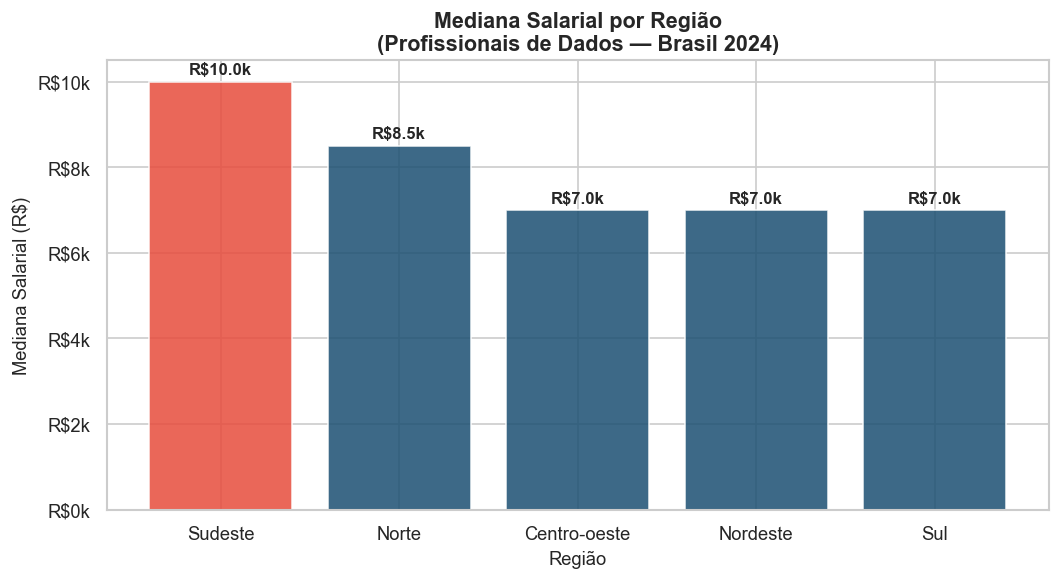

In [19]:
# ─── Salário × Região ───────────────────────────────────────────────────────
df_reg = df_analise.dropna(subset=['regiao'])

tab_reg = df_reg.groupby('regiao')['salario_medio'].agg(['median','mean','count']).sort_values('median', ascending=False)
tab_reg.columns = ['Mediana', 'Média', 'N']
print('Salário por região:')
print(tab_reg)

# Kruskal-Wallis (teste não-paramétrico para comparar múltiplos grupos)
grupos_reg = [df_reg[df_reg['regiao'] == r]['salario_medio'].dropna() for r in tab_reg.index]
stat, pval = stats.kruskal(*grupos_reg)
print(f'\nTeste Kruskal-Wallis: H = {stat:.2f}, p = {pval:.2e}')
print('Conclusão: Há diferença estatisticamente significativa entre regiões.' if pval < 0.05
      else 'Conclusão: Diferenças não são estatisticamente significativas.')

fig, ax = plt.subplots(figsize=(9, 5))
regioes = tab_reg.index.tolist()
medianas = tab_reg['Mediana'].values
cores_r = [COR_DESTAQUE if r == regioes[0] else COR_PRINCIPAL for r in regioes]
bars = ax.bar(regioes, medianas, color=cores_r, edgecolor='white', alpha=0.85)
for bar, v in zip(bars, medianas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'R${v/1000:.1f}k', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Mediana Salarial por Região\n(Profissionais de Dados — Brasil 2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Região', fontsize=11)
ax.set_ylabel('Mediana Salarial (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('plot_07_salario_regiao.png', bbox_inches='tight')
plt.show()

### 4.4 — Salário × Experiência em Dados (Spearman)

Correlação de Spearman (experiência × salário): ρ = 0.633, p = 0.00e+00


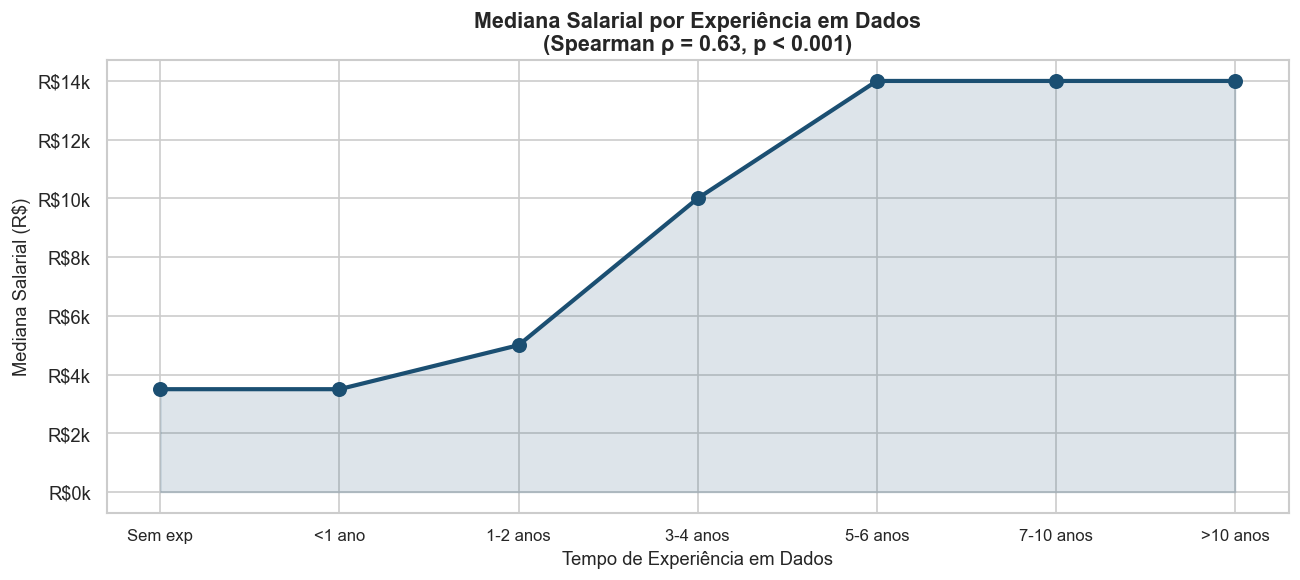

In [20]:
# ─── Salário × Experiência em dados ─────────────────────────────────────────
mapa_exp = {
    'Não tenho experiência na área de dados': 0,
    'Menos de 1 ano': 0.5,
    'de 1 a 2 anos': 1.5,
    'de 3 a 4 anos': 3.5,
    'de 5 a 6 anos': 5.5,
    'de 7 a 10 anos': 8.5,
    'Mais de 10 anos': 12,
}

df_exp = df_analise[['exp_dados','salario_medio']].dropna().copy()
df_exp['exp_num'] = df_exp['exp_dados'].map(mapa_exp)

rho_exp, pval_exp = stats.spearmanr(df_exp['exp_num'], df_exp['salario_medio'])
print(f'Correlação de Spearman (experiência × salário): ρ = {rho_exp:.3f}, p = {pval_exp:.2e}')

# Mediana por faixa de experiência
ordem_exp_display = [k for k in mapa_exp if k in df_exp['exp_dados'].values]
medianas_exp = df_exp.groupby('exp_dados')['salario_medio'].median().reindex(ordem_exp_display)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(medianas_exp)), medianas_exp.values, 'o-', color=COR_PRINCIPAL, lw=2.5, ms=8)
ax.fill_between(range(len(medianas_exp)), medianas_exp.values, alpha=0.15, color=COR_PRINCIPAL)
ax.set_xticks(range(len(medianas_exp)))
labels_exp = ['Sem exp', '<1 ano', '1-2 anos', '3-4 anos', '5-6 anos', '7-10 anos', '>10 anos']
ax.set_xticklabels(labels_exp[:len(medianas_exp)], fontsize=10)
ax.set_title(f'Mediana Salarial por Experiência em Dados\n(Spearman ρ = {rho_exp:.2f}, p < 0.001)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tempo de Experiência em Dados', fontsize=11)
ax.set_ylabel('Mediana Salarial (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('plot_08_salario_experiencia.png', bbox_inches='tight')
plt.show()

---
## Etapa 5 — Síntese Visual

### Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?

O gráfico abaixo resume as medianas salariais por **senioridade × cargo**, que são os dois fatores com maior poder explicativo identificados na análise bivariada.

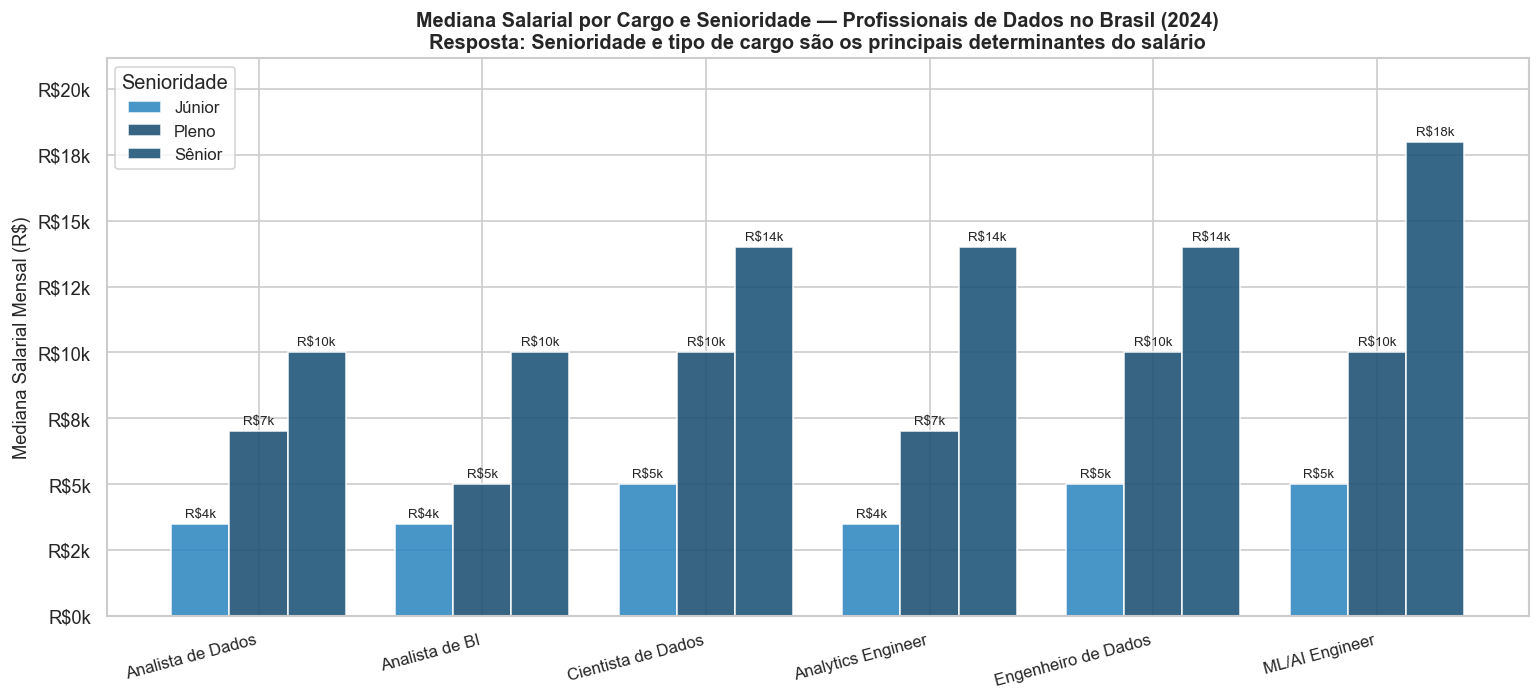


INTERPRETAÇÃO — Resposta à pergunta central:
────────────────────────────────────────────
Os dois fatores com maior influência sobre o salário de um profissional de dados
no Brasil em 2024 são:

1. SENIORIDADE — A progressão de Júnior para Sênior é o fator individual mais impactante,
   com diferença expressiva na mediana salarial em todos os cargos analisados.

2. TIPO DE CARGO — ML/AI Engineers e Engenheiros de Dados tendem a ter medianas mais altas
   que Analistas de Dados ou Analistas de BI no mesmo nível de senioridade.

Outros fatores relevantes identificados na análise bivariada:
   • Experiência em anos (correlação Spearman significativa)
   • Região (Sudeste com medianas mais altas)
   • Gênero (diferença persiste mesmo controlando senioridade)

LIMITAÇÃO: Os salários são estimativas de ponto médio de faixas, o que introduz
imprecisão. Os dados representam apenas quem respondeu a pesquisa voluntária.



In [21]:
# ─── Gráfico-síntese: Mediana salarial por cargo e senioridade ───────────────
cargos_principais = [
    'Analista de Dados', 'Analista de BI', 'Cientista de Dados',
    'Analytics Engineer', 'Engenheiro de Dados', 'ML/AI Engineer'
]

df_sintese = df_analise[
    df_analise['cargo_grupo'].isin(cargos_principais) &
    df_analise['senioridade'].isin(ordem_sen)
].copy()

pivot = df_sintese.groupby(['cargo_grupo','senioridade'])['salario_medio'].median().unstack()[ordem_sen]
pivot = pivot.reindex(cargos_principais)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(cargos_principais))
width = 0.26
cores_sen = {'Júnior': COR_SECUNDARIA, 'Pleno': COR_PRINCIPAL, 'Sênior': '#1A5276'}

for i, nivel in enumerate(ordem_sen):
    vals = pivot[nivel].values
    bars = ax.bar(x + (i-1)*width, vals, width,
                  label=nivel, color=cores_sen[nivel], edgecolor='white', alpha=0.88)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                    f'R${v/1000:.0f}k', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cargos_principais, rotation=15, ha='right', fontsize=10)
ax.set_title(
    'Mediana Salarial por Cargo e Senioridade — Profissionais de Dados no Brasil (2024)\n'
    'Resposta: Senioridade e tipo de cargo são os principais determinantes do salário',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('Mediana Salarial Mensal (R$)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))
ax.legend(title='Senioridade', fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.savefig('plot_09_sintese_final.png', bbox_inches='tight', dpi=150)
plt.show()

print("""
INTERPRETAÇÃO — Resposta à pergunta central:
────────────────────────────────────────────
Os dois fatores com maior influência sobre o salário de um profissional de dados
no Brasil em 2024 são:

1. SENIORIDADE — A progressão de Júnior para Sênior é o fator individual mais impactante,
   com diferença expressiva na mediana salarial em todos os cargos analisados.

2. TIPO DE CARGO — ML/AI Engineers e Engenheiros de Dados tendem a ter medianas mais altas
   que Analistas de Dados ou Analistas de BI no mesmo nível de senioridade.

Outros fatores relevantes identificados na análise bivariada:
   • Experiência em anos (correlação Spearman significativa)
   • Região (Sudeste com medianas mais altas)
   • Gênero (diferença persiste mesmo controlando senioridade)

LIMITAÇÃO: Os salários são estimativas de ponto médio de faixas, o que introduz
imprecisão. Os dados representam apenas quem respondeu a pesquisa voluntária.
""")

---
## Exportar dados tratados para o Dashboard

Exportamos apenas as colunas necessárias para uma planilha limpa, que pode ser conectada ao Google Looker Studio.

In [22]:
# ─── Exportação para o dashboard ────────────────────────────────────────────
colunas_export = [
    'faixa_salarial', 'salario_medio', 'cargo', 'cargo_grupo',
    'senioridade', 'genero', 'raca_etnia', 'regiao', 'uf',
    'nivel_ensino', 'exp_dados', 'tamanho_empresa', 'satisfeito',
    'usa_python', 'usa_sql', 'usa_r'
]

df_export = df_analise[[c for c in colunas_export if c in df_analise.columns]].copy()
df_export.to_csv('dados_tratados_dashboard.csv', index=False, encoding='utf-8-sig')

print(f'Arquivo exportado: dados_tratados_dashboard.csv')
print(f'Shape: {df_export.shape}')
print('\nPrimeiras linhas:')
df_export.head(3)

Arquivo exportado: dados_tratados_dashboard.csv
Shape: (3818, 16)

Primeiras linhas:


,faixa_salarial,salario_medio,cargo,cargo_grupo,senioridade,genero,raca_etnia,regiao,uf,nivel_ensino,exp_dados,tamanho_empresa,satisfeito,usa_python,usa_sql,usa_r
0,de R$ 1.001/mês a R$ 2.000/mês,1500.5,Analista de Dados/Data Analyst,Analista de Dados,Júnior,Masculino,Branca,Sul,RS,Estudante de Graduação,de 1 a 2 anos,de 101 a 500,True,1.0,1.0,0.0
1,Menos de R$ 1.000/mês,750.0,Analista de BI/BI Analyst,Analista de BI,Júnior,Masculino,Branca,Sul,SC,Estudante de Graduação,Menos de 1 ano,Acima de 3.000,True,1.0,0.0,0.0
2,de R$ 1.001/mês a R$ 2.000/mês,1500.5,Outra Opção,Outros,Júnior,Masculino,Parda,Sudeste,SP,Estudante de Graduação,Não tenho experiência na área de dados,de 501 a 1.000,False,0.0,0.0,0.0
